In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [7]:
df = pd.read_csv("telecom_churn.csv")
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [10]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 3333
Columns: 11


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [12]:
df.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [13]:
df.isnull().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

Observation:
- Dataset contains 3333 records.
- No missing values were found.
- No duplicate records were detected.

In [4]:
duplicate_count = df.duplicated().sum()

if duplicate_count == 0:
    print("No duplicate records")
else:
    print(f"Number of duplicate rows: {duplicate_count}")

No duplicate records


In [ ]:
numeric_cols = [
    col for col in df.select_dtypes(include='number').columns
    if col != 'Churn' and df[col].nunique() > 2
]

outlier_before = []

#Checking
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | 
                  (df[col] > upper)]

    outlier_before.append({
        "Feature": col,
        "Outliers Before": len(outliers)
    })

outlier_before = pd.DataFrame(outlier_before)

df_clean = df.copy()

#Cleaning
for col in numeric_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

outlier_after = []

#Re-check
for col in numeric_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower) | 
                        (df_clean[col] > upper)]

    outlier_after.append({
        "Feature": col,
        "Outliers After": len(outliers)
    })

outlier_after = pd.DataFrame(outlier_after)

#Table
outlier_comparison = outlier_before.merge(
    outlier_after,
    on="Feature"
)

print(f"Original Shape: {df.shape}")
print(f"Cleaned Shape: {df_clean.shape}")
print(f"Rows Removed: {df.shape[0] - df_clean.shape[0]}")

display(outlier_comparison)

Original Shape: (3333, 11)
Cleaned Shape: (2903, 11)
Rows Removed: 430


,Feature,Outliers Before,Outliers After
0,AccountWeeks,18,0
1,DataUsage,11,3
2,CustServCalls,267,0
3,DayMins,25,1
4,DayCalls,23,2
5,MonthlyCharge,34,4
6,OverageFee,24,1
7,RoamMins,46,0


In [24]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[numeric_cols])

scaled_df = pd.DataFrame(scaled_data, columns=numeric_cols)

print("Standardized Data:")
display(scaled_df.head())

Standardized Data:


,AccountWeeks,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0.676489,1.480204,-0.427932,1.566767,0.476643,1.990727,-0.071584,-0.085008
1,0.149065,2.266072,-0.427932,-0.333738,1.124503,1.564510,-0.107082,1.240482
2,0.902529,-0.641642,-1.188218,1.168304,0.675985,-0.262133,-1.574346,0.703121
3,-0.428590,-0.641642,0.332354,2.196596,-1.466936,0.042307,-2.741846,-1.303026
4,-0.654629,-0.641642,1.092641,-0.240090,0.626149,-0.931902,-1.037927,-0.049184


In [25]:
normalizer = MinMaxScaler()

normalized_data = normalizer.fit_transform(df[numeric_cols])

normalized_df = pd.DataFrame(normalized_data, columns=numeric_cols)

print("Normalized Data:")
display(normalized_df.head())

Normalized Data:


,AccountWeeks,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0.524793,0.500000,0.111111,0.755701,0.666667,0.770812,0.542606,0.500
1,0.438017,0.685185,0.111111,0.460661,0.745455,0.698869,0.537658,0.685
2,0.561983,0.000000,0.000000,0.693843,0.690909,0.390545,0.333150,0.610
3,0.342975,0.000000,0.222222,0.853478,0.430303,0.441932,0.170423,0.330
4,0.305785,0.000000,0.333333,0.475200,0.684848,0.277492,0.407916,0.505


In [26]:
selected_features = [
    'AccountWeeks',
    'ContractRenewal',
    'CustServCalls',
    'DayMins',
    'MonthlyCharge',
    'OverageFee',
    'RoamMins',
    'DataUsage'
]

target = 'Churn'

df_selected = df[selected_features + [target]]

print("\nSelected Features =")
display(pd.DataFrame(selected_features, columns=["Selected Features"]))

print("\nNew Dataset Shape =")
print(df_selected.shape)

print("\nSelected Dataset Preview:")
display(df_selected.head())


Selected Features =


,Selected Features
0,AccountWeeks
1,ContractRenewal
2,CustServCalls
3,DayMins
4,MonthlyCharge
5,OverageFee
6,RoamMins
7,DataUsage



New Dataset Shape =
(3333, 9)

Selected Dataset Preview:


,AccountWeeks,ContractRenewal,CustServCalls,DayMins,MonthlyCharge,OverageFee,RoamMins,DataUsage,Churn
0,128,1,1,265.1,89.0,9.87,10.0,2.7,0
1,107,1,1,161.6,82.0,9.78,13.7,3.7,0
2,137,1,0,243.4,52.0,6.06,12.2,0.0,0
3,84,0,2,299.4,57.0,3.10,6.6,0.0,0
4,75,0,3,166.7,41.0,7.42,10.1,0.0,0


In [37]:
df_clean.to_csv("telecom_churn_cleaned.csv", index=False)

In [28]:
X = df_selected.drop("Churn", axis=1)
y = df_selected["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

split_table = pd.DataFrame({
    "Dataset": ["X_train","X_test","y_train","y_test"],
    "Rows":[X_train.shape[0], X_test.shape[0], y_train.shape[0], y_test.shape[0]],
    "Columns":[X_train.shape[1], X_test.shape[1], "-", "-"]
})

display(split_table)

,Dataset,Rows,Columns
0,X_train,2666,8
1,X_test,667,8
2,y_train,2666,-
3,y_test,667,-


In [29]:
#Logistic Regression
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

cm_log = confusion_matrix(y_test, y_pred_log)

cm_log_table = pd.DataFrame(cm_log,
                            index=["Actual No Churn","Actual Churn"],
                            columns=["Predicted No Churn","Predicted Churn"])

display(cm_log_table)

log_metrics = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1-score"],
    "Score": [
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log)
    ]
})

print("Logistic Regression Performance")
display(log_metrics)

,Predicted No Churn,Predicted Churn
Actual No Churn,553,17
Actual Churn,77,20


Logistic Regression Performance


,Metric,Score
0,Accuracy,0.859070
1,Precision,0.540541
2,Recall,0.206186
3,F1-score,0.298507


In [30]:
#Regression
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf_table = pd.DataFrame(cm_rf,
                           index=["Actual No Churn","Actual Churn"],
                           columns=["Predicted No Churn","Predicted Churn"])

display(cm_rf_table)

rf_metrics = pd.DataFrame({
    "Metric": ["Accuracy","Precision","Recall","F1-score"],
    "Score": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ]
})

print("Random Forest Performance")
display(rf_metrics)

,Predicted No Churn,Predicted Churn
Actual No Churn,557,13
Actual Churn,36,61


Random Forest Performance


,Metric,Score
0,Accuracy,0.926537
1,Precision,0.824324
2,Recall,0.628866
3,F1-score,0.713450


In [32]:
comparison = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[accuracy_score(y_test,y_pred_log),
                accuracy_score(y_test,y_pred_rf)],
    "Precision":[precision_score(y_test,y_pred_log),
                 precision_score(y_test,y_pred_rf)],
    "Recall":[recall_score(y_test,y_pred_log),
              recall_score(y_test,y_pred_rf)],
    "F1-score":[f1_score(y_test,y_pred_log),
                f1_score(y_test,y_pred_rf)]
})

print("Model Comparison")
display(comparison)

Model Comparison


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.859070,0.540541,0.206186,0.298507
1,Random Forest,0.926537,0.824324,0.628866,0.713450


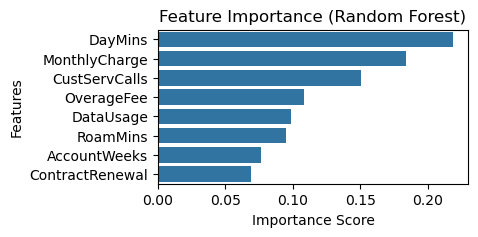

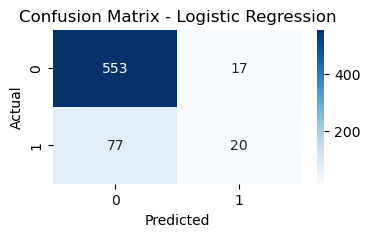

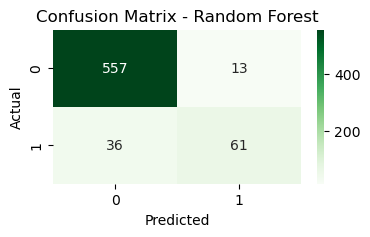

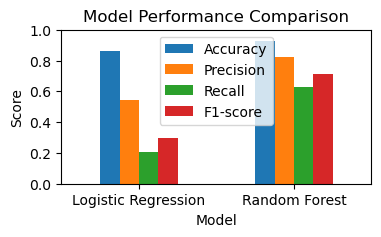

In [34]:
importances = rf_model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(4,2))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df
)

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(4,2))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(4,2))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(4,2)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1)

plt.xticks(rotation=0)

plt.show()

In [35]:
#How many customer churn?
churn_rate = df["Churn"].mean() * 100
print(f"Customer Churn Rate: {churn_rate:.2f}%")

Customer Churn Rate: 14.49%


Business Insight
1. How many customer churn??
-> Approximately 14.5% of customers have churned.

2. Why do customers churn?
1) High Monthly Charges Increase Churn Risk.
2) Frequent Customer Service Calls Are Associated with Higher Churn
3) High Daytime Usage Customers Are More Likely to Churn